In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Selection and download of the asset prices

In [22]:
ASSETS = ["GS", "MS", "SCHW", "JNJ", "ABBV","TMO","XOM","SLB","EOG","COST","NKE","SBUX","CAT","DE","UPS","AMD","ORCL","CRM","CMCSA","LIN"]
n_assets = len(ASSETS)

prices_df = yf.download(
    ASSETS,
    start="2017-01-01",
    end="2023-12-31",
    auto_adjust=False
)

prices = prices_df["Adj Close"]

[*********************100%***********************]  20 of 20 completed


## 2. Grouping and plots of Assets per Sector

In [20]:
financials = ["GS", "MS", "SCHW"]
healthcare = ["JNJ", "ABBV", "TMO"]
energy = ["XOM", "SLB", "EOG"]
technology = ["AMD", "ORCL", "CRM", "CMCSA"]
industrials = ["CAT", "DE", "UPS", "LIN"]
consumer = ["COST", "NKE", "SBUX"]

<Figure size 1000x600 with 0 Axes>

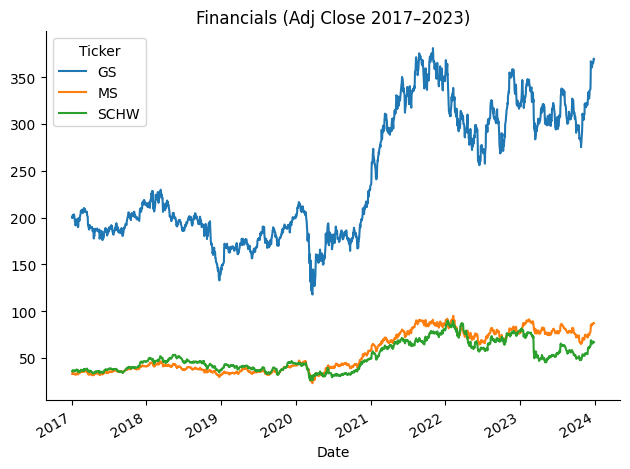

<Figure size 1000x600 with 0 Axes>

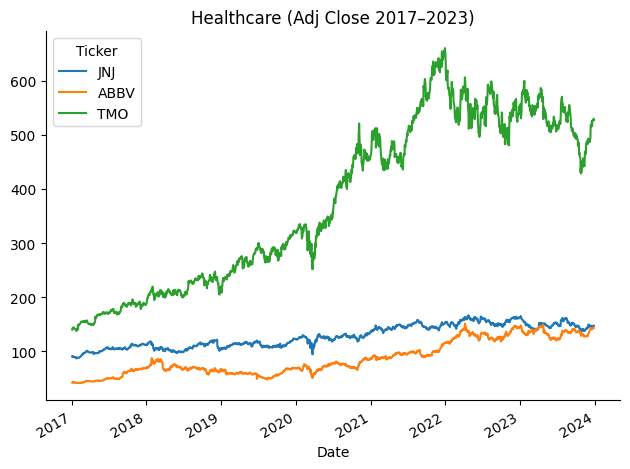

<Figure size 1000x600 with 0 Axes>

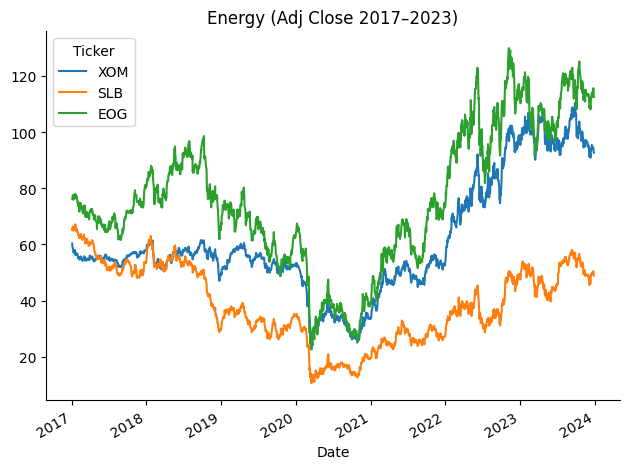

<Figure size 1000x600 with 0 Axes>

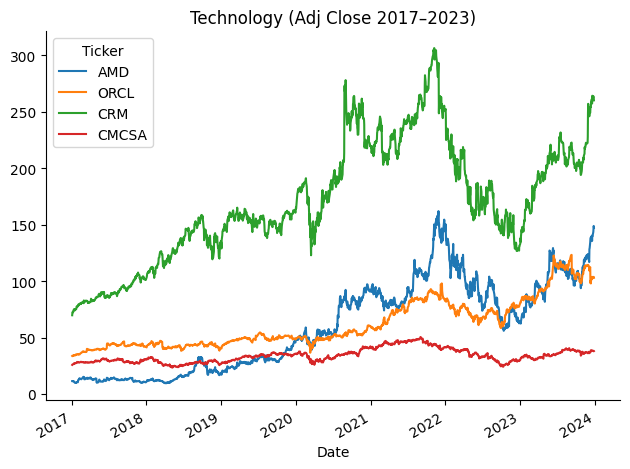

<Figure size 1000x600 with 0 Axes>

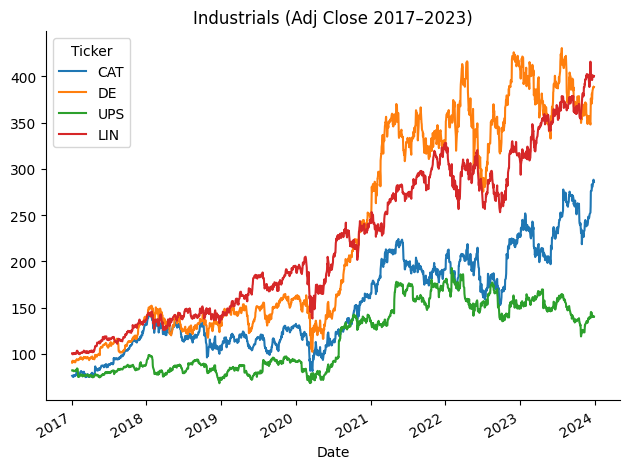

<Figure size 1000x600 with 0 Axes>

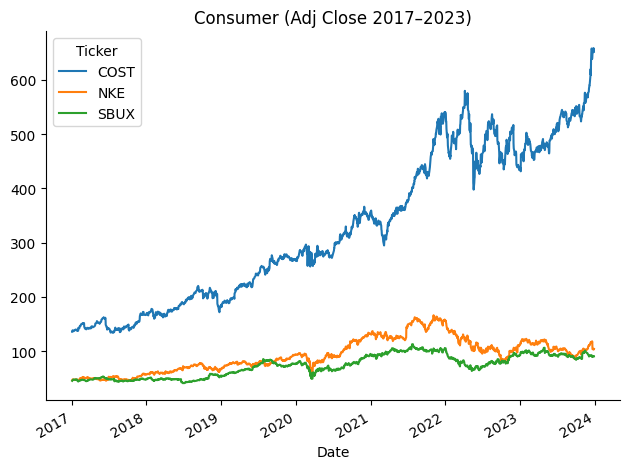

In [21]:
plt.figure(figsize=(10,6))
prices[financials].plot(title="Financials (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
prices[healthcare].plot(title="Healthcare (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
prices[energy].plot(title="Energy (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
prices[technology].plot(title="Technology (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
prices[industrials].plot(title="Industrials (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
prices[consumer].plot(title="Consumer (Adj Close 2017–2023)")
sns.despine()
plt.tight_layout()
plt.show()

## 3. 1/n asset allocation

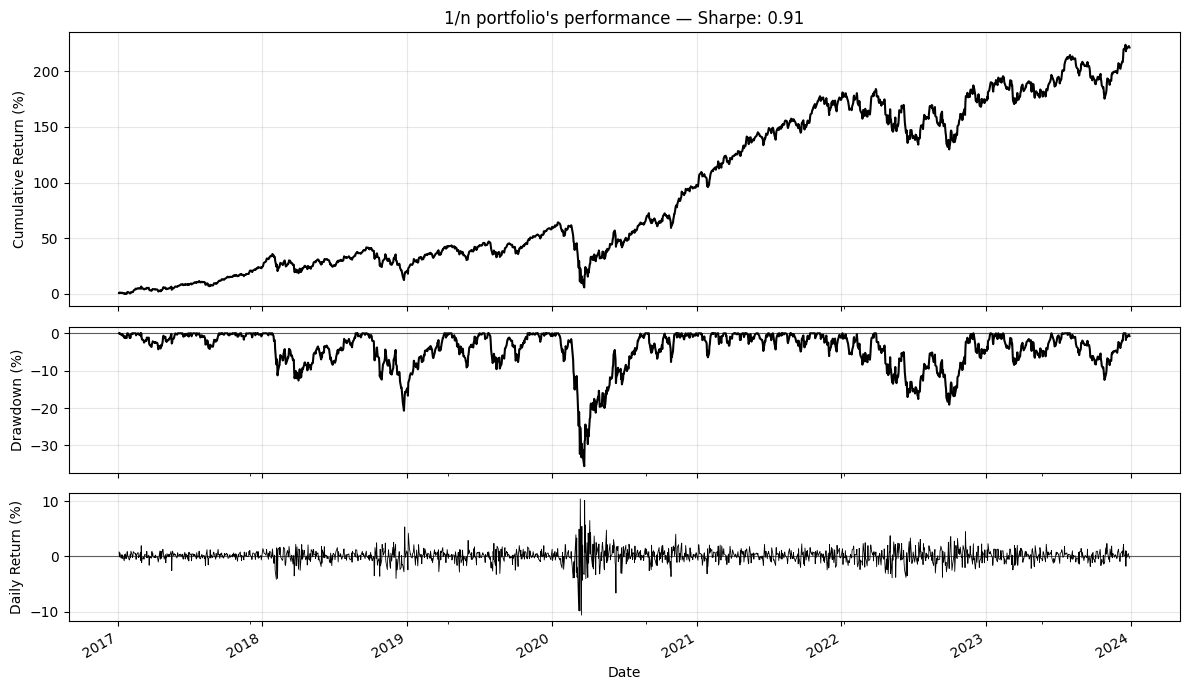

In [23]:
returns_df = prices.pct_change().dropna()

portfolio_weights = n_assets * [1 / n_assets]

portfolio_returns = pd.Series(
    np.dot(portfolio_weights, returns_df.T),
    index=returns_df.index
)

equity = (1 + portfolio_returns).cumprod()
running_max = equity.cummax()
drawdown = equity / running_max - 1
sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1.6, 1.4]})

# Cumulative Return
(equity - 1).mul(100).plot(ax=axes[0], color="black")
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].set_title(f"1/n portfolio's performance — Sharpe: {sharpe:.2f}")
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown.mul(100).plot(ax=axes[1], color="black")
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(True, alpha=0.3)

# Daily returns
portfolio_returns.mul(100).plot(ax=axes[2], color="black", linewidth=0.6)
axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[2].set_ylabel("Daily Return (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Monte Carlo Simulation

In [90]:
# Setting up parameters

N_PORTFOLIOS = 10**6
N_DAYS = 252
prices_df.head()

Price       Adj Close                                                      \
Ticker           ABBV    AMD        CAT      CMCSA        COST        CRM   
Date                                                                        
2017-01-03  42.428444  11.43  76.428352  25.783688  135.761841  69.693207   
2017-01-04  43.026699  11.43  76.086823  26.089876  135.787308  71.926086   
2017-01-05  43.353012  11.24  75.623322  26.194441  138.464645  71.916206   
2017-01-06  43.366615  11.32  75.655838  26.239246  138.396637  72.914078   
2017-01-09  43.652138  11.49  75.111031  26.448345  136.815704  73.072159   

Price                                                    ...   Volume  \
Ticker             DE        EOG          GS        JNJ  ...      LIN   
Date                                                     ...            
2017-01-03  90.600838  76.249451  199.930832  90.299965  ...  2364200   
2017-01-04  92.142105  76.308357  201.221909  90.151863  ...  1564800   
2017-01-05  91.732834  76.720772  199.723877  91.095085  ...  1756500   
2017-01-06  92.725464  77.479256  202.686798  90.658554  ...  1907500   
2017-01-09  91.593513  75.866508  201.023285  90.642960  ...  1143700   

Price                                                                          \
Ticker            MS       NKE      ORCL      SBUX     SCHW      SLB      TMO   
Date                                                                            
2017-01-03   8316900  13295600  11051300   7809300  6950900  6667100  1966400   
2017-01-04   7747400  13759500   9545500   7796300  8892900  4655400  2167200   
2017-01-05   9883200   8682200  12064700   7602300  6336200  4543000  1683500   
2017-01-06   9152800  12532400  14829700   8587800  5639700  5689900  2016200   
2017-01-09  11104000   8835300  15587900  12640500  4413500  4336500  1967200   

Price                          
Ticker          UPS       XOM  
Date                           
2017-01-03  2390700  10360600  
2017-01-04  1830800   9434200  
2017-01-05  1856200  14443200  
2017-01-06  1767000  16518100  
2017-01-09  1965200  13762300  

[5 rows x 120 columns]

In [91]:
returns_df = prices.pct_change().dropna()

avg_returns = returns_df.mean() * N_DAYS
cov_mat = returns_df.cov() * N_DAYS

print(avg_returns.shape)
print(cov_mat.shape)
print(n_assets)

(20,)
(20, 20)
20


<Figure size 1000x600 with 0 Axes>

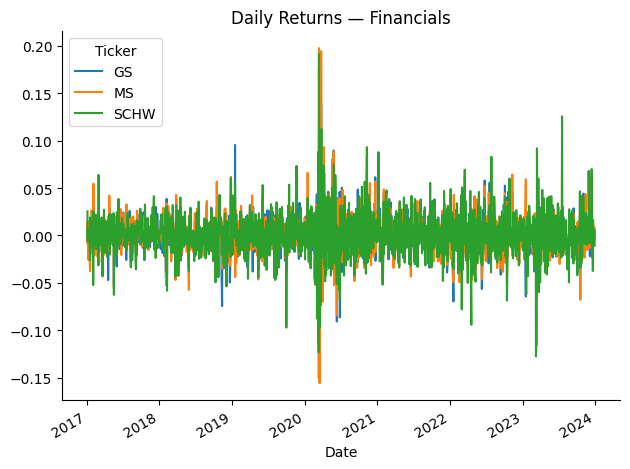

<Figure size 1000x600 with 0 Axes>

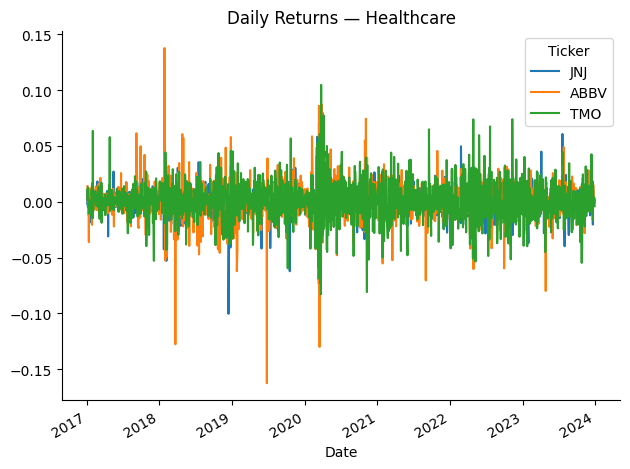

<Figure size 1000x600 with 0 Axes>

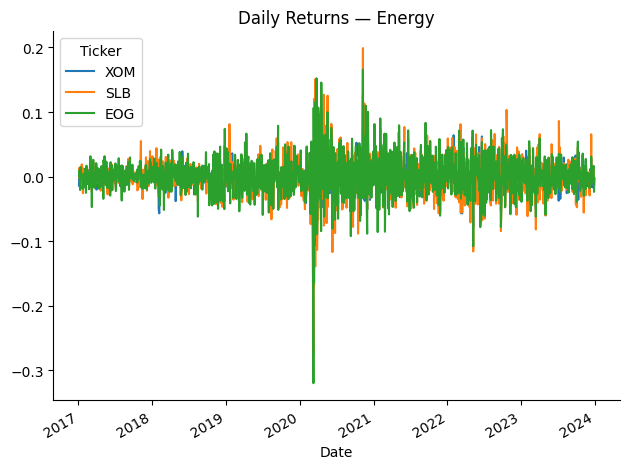

<Figure size 1000x600 with 0 Axes>

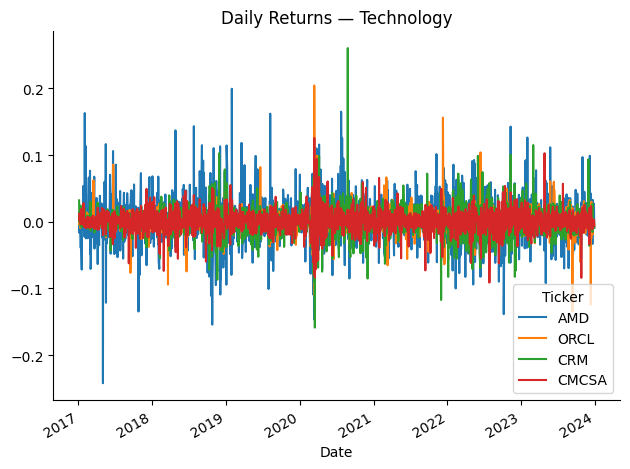

<Figure size 1000x600 with 0 Axes>

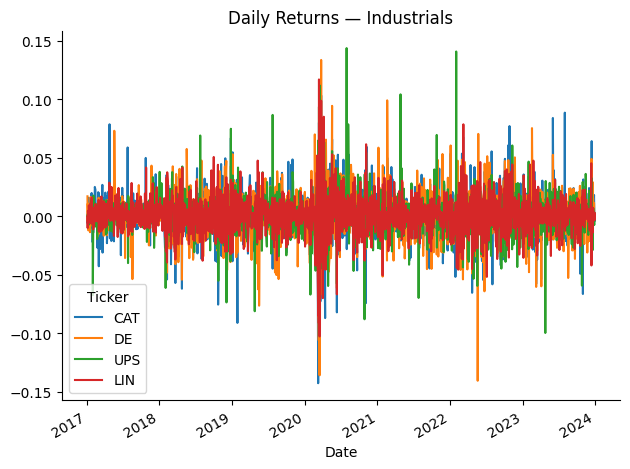

<Figure size 1000x600 with 0 Axes>

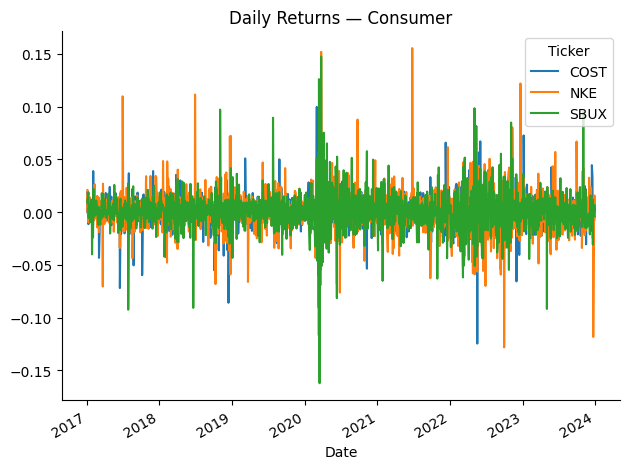

In [92]:
plt.figure(figsize=(10,6))
returns_df[financials].plot(title="Daily Returns — Financials")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
returns_df[healthcare].plot(title="Daily Returns — Healthcare")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
returns_df[energy].plot(title="Daily Returns — Energy")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
returns_df[technology].plot(title="Daily Returns — Technology")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
returns_df[industrials].plot(title="Daily Returns — Industrials")
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
returns_df[consumer].plot(title="Daily Returns — Consumer")
sns.despine()
plt.tight_layout()
plt.show()

In [93]:
np.random.seed(42)

# 5) Simulate random portfolio weights
weights = np.random.random(size=(N_PORTFOLIOS, n_assets))
weights /= np.sum(weights, axis=1)[:, np.newaxis]

# 6) Calculate portfolio returns
portf_rtns = np.dot(weights, avg_returns.values)

# 6) Calculate portfolio volatilities (book loop)
portf_vol = []
for i in range(0, len(weights)):
    vol = np.sqrt(
        np.dot(weights[i].T, np.dot(cov_mat.values, weights[i]))
    )
    portf_vol.append(vol)

portf_vol = np.array(portf_vol)

# Sharpe ratio (rf = 0)
portf_sharpe_ratio = portf_rtns / portf_vol

# 7) Create DataFrame
portf_results_df = pd.DataFrame({
    "returns": portf_rtns,
    "volatility": portf_vol,
    "sharpe_ratio": portf_sharpe_ratio
})

portf_results_df

,returns,volatility,sharpe_ratio
0,0.197656,0.221709,0.891512
1,0.178472,0.206980,0.862265
2,0.191172,0.216199,0.884240
3,0.175337,0.208782,0.839808
4,0.196917,0.216634,0.908984
...,...,...,...
999995,0.196819,0.198667,0.990697
999996,0.177167,0.206226,0.859095
999997,0.213410,0.214597,0.994468
999998,0.191232,0.224256,0.852741


In [94]:
# 8. Locate the points creating the Efficient Frontier:

N_POINTS = 5000

ef_rtn_list = []
ef_vol_list = []

possible_ef_rtns = np.linspace(
    portf_results_df["returns"].min(),
    portf_results_df["returns"].max(),
    N_POINTS
)

possible_ef_rtns = np.round(possible_ef_rtns, 2)
portf_rtns_rounded = np.round(portf_rtns, 2)

for rtn in possible_ef_rtns:
    if rtn in portf_rtns_rounded:
        ef_rtn_list.append(rtn)
        matched_ind = np.where(portf_rtns_rounded == rtn)
        ef_vol_list.append(np.min(portf_vol[matched_ind]))

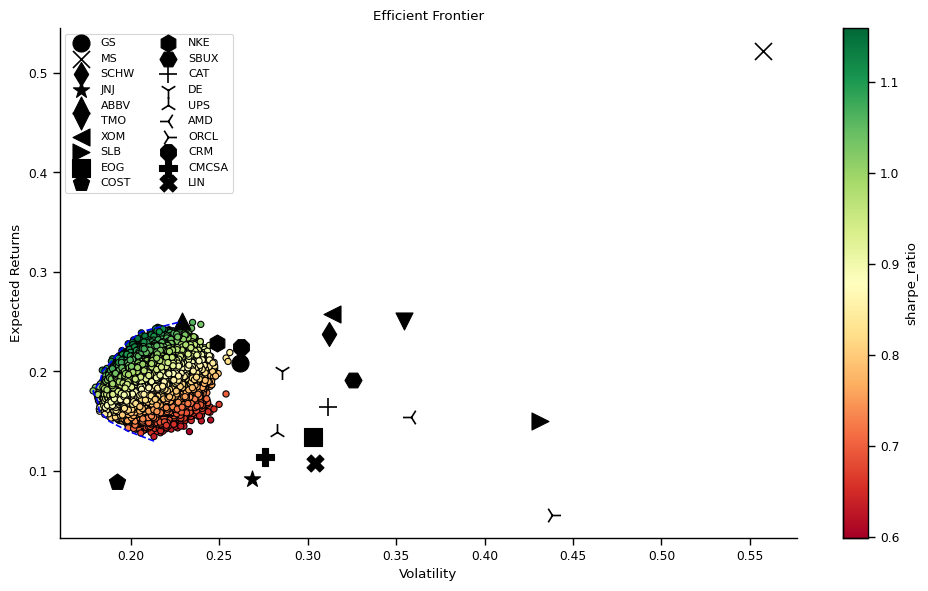

In [95]:
MARKERS = ["o", "x", "d", "*", "^", "v", "<", ">", "s", "p", "h", "H", "+", "1", "2", "3", "4", "8", "P", "X"]

with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(10, 6))

    portf_results_df.plot(
        kind="scatter",
        x="volatility",
        y="returns",
        c="sharpe_ratio",
        cmap="RdYlGn",
        edgecolors="black",
        ax=ax
    )

    ax.set(
        xlabel="Volatility",
        ylabel="Expected Returns",
        title="Efficient Frontier"
    )

    # Efficient frontier curve
    ax.plot(ef_vol_list, ef_rtn_list, "b--")

    # Plot individual assets (annualized vol on x, annualized mean return on y)
    for asset_index in range(n_assets):
        ax.scatter(
            x=np.sqrt(cov_mat.iloc[asset_index, asset_index]),
            y=avg_returns.iloc[asset_index],
            marker=MARKERS[asset_index],
            s=150,
            color="black",
            label=ASSETS[asset_index]
        )

    ax.legend(loc="best", fontsize=8, ncol=2)
    sns.despine()
    plt.tight_layout()

In [96]:
# Indices of special portfolios
idx_min_var = portf_results_df["volatility"].idxmin()
idx_max_ret = portf_results_df["returns"].idxmax()
idx_min_ret = portf_results_df["returns"].idxmin()
idx_max_sharpe = portf_results_df["sharpe_ratio"].idxmax()

special = {
    "Min Variance": idx_min_var,
    "Max Return": idx_max_ret,
    "Min Return": idx_min_ret,
    "Max Sharpe": idx_max_sharpe
}

# Show their stats (optional)
portf_results_df.loc[list(special.values())]

,returns,volatility,sharpe_ratio
835898,0.180506,0.178653,1.010373
9647,0.249271,0.234900,1.061181
991788,0.134602,0.213080,0.631696
34416,0.238788,0.205969,1.159342


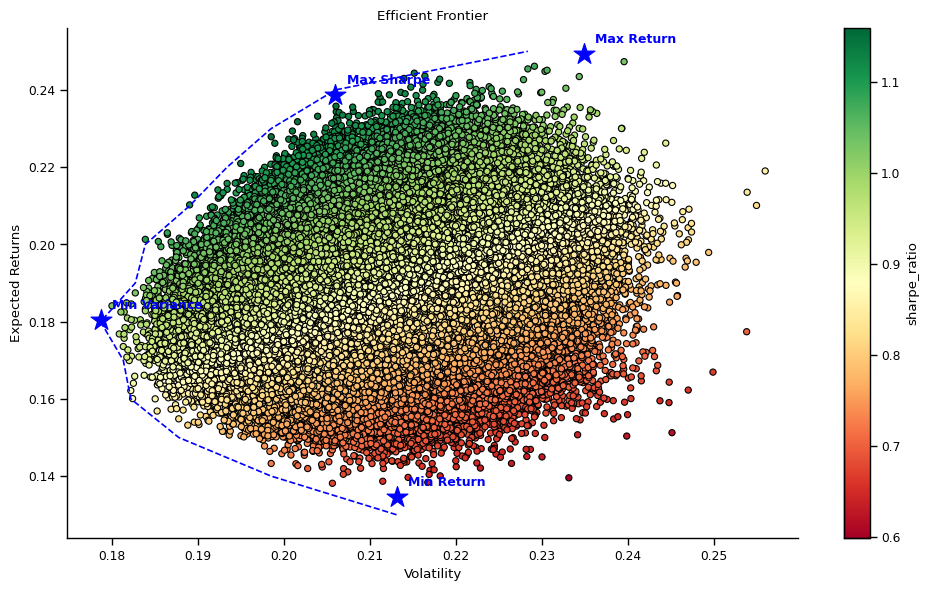

In [97]:
with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Monte Carlo cloud
    portf_results_df.plot(
        kind="scatter",
        x="volatility",
        y="returns",
        c="sharpe_ratio",
        cmap="RdYlGn",
        edgecolors="black",
        ax=ax
    )

    # Efficient frontier curve
    ax.plot(ef_vol_list, ef_rtn_list, "b--")

    ax.set(xlabel="Volatility", ylabel="Expected Returns", title="Efficient Frontier")

    # ---- Highlight special portfolios ----
    for name, idx in special.items():
        x = portf_results_df.loc[idx, "volatility"]
        y = portf_results_df.loc[idx, "returns"]

        ax.scatter(x, y, s=250, color="blue", marker="*", zorder=5)
        ax.annotate(name, (x, y), xytext=(8, 8), textcoords="offset points",
                    fontsize=9, color="blue", weight="bold")

    sns.despine()
    plt.tight_layout()
    plt.show()

## Finding the efficient frontier using convex optimization with `cvxpy`

In [98]:
import cvxpy as cp

In [99]:
# Convert to numpy arrays
avg_returns_np = avg_returns.values
cov_mat_np = cov_mat.values

In [100]:
# Setting up the optimization problem
weights = cp.Variable(n_assets)
gamma_par = cp.Parameter(nonneg=True)

portf_rtn_cvx = avg_returns_np @ weights
portf_var_cvx = cp.quad_form(weights, cov_mat_np)  # variance term (not sqrt)

objective_function = cp.Maximize(
    portf_rtn_cvx - gamma_par * portf_var_cvx
)

problem = cp.Problem(
    objective_function,
    [cp.sum(weights) == 1, weights >= 0]
)

In [101]:
N_POINTS = 50

portf_rtn_cvx_ef = []
portf_vol_cvx_ef = []
weights_ef = []

gamma_range = np.logspace(-3, 3, num=N_POINTS)

for gamma in gamma_range:
    gamma_par.value = gamma
    problem.solve()

    portf_vol_cvx_ef.append(np.sqrt(portf_var_cvx.value))
    portf_rtn_cvx_ef.append(portf_rtn_cvx.value)
    weights_ef.append(weights.value)

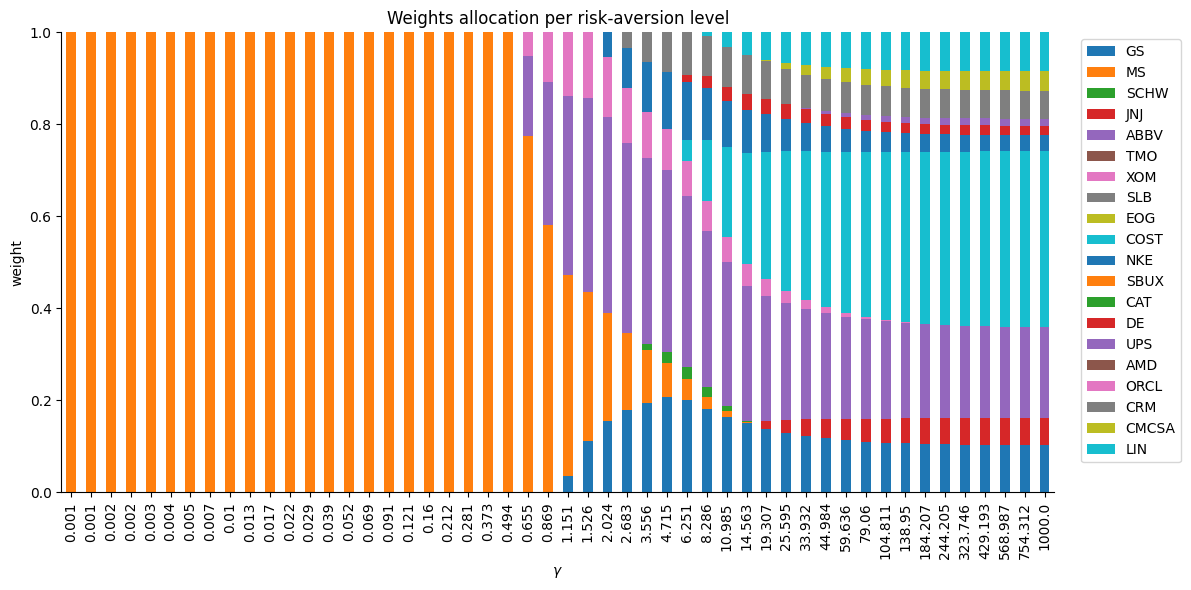

In [102]:
weights_df = pd.DataFrame(weights_ef, columns=ASSETS, index=np.round(gamma_range, 3))

ax = weights_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set(title="Weights allocation per risk-aversion level",
       xlabel=r"$\gamma$",
       ylabel="weight")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

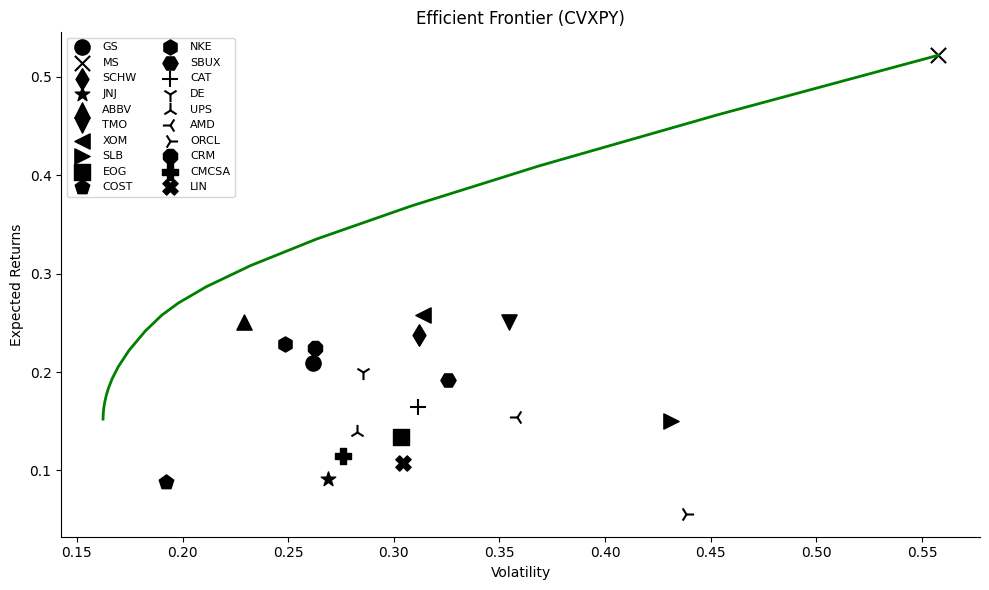

In [103]:
# Plot the Efficient Frontier together with the individual assets:

MARKERS = ["o", "x", "d", "*", "^", "v", "<", ">", "s", "p", "h", "H",
           "+", "1", "2", "3", "4", "8", "P", "X"]

fig, ax = plt.subplots(figsize=(10, 6))

# CVXPY efficient frontier (volatility on x, returns on y)
ax.plot(portf_vol_cvx_ef, portf_rtn_cvx_ef, "g-", linewidth=2)

# Individual assets
for asset_index in range(n_assets):
    ax.scatter(
        x=np.sqrt(cov_mat_np[asset_index, asset_index]),
        y=avg_returns_np[asset_index],
        marker=MARKERS[asset_index],
        s=120,
        color="black",
        label=ASSETS[asset_index]
    )

ax.set(title="Efficient Frontier (CVXPY)",
       xlabel="Volatility",
       ylabel="Expected Returns")

ax.legend(loc="best", fontsize=8, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()